<a href="https://colab.research.google.com/github/Teyoltlahui23/26-spring-stats-21/blob/main/HW4_Teyoltlahui.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numpy import random
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="ticks", color_codes=True,font_scale=1.75)
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from google.colab import drive
drive.mount('/content/drive') # connect to your google drive
df = pd.read_csv('/content/drive/MyDrive/GEOG191_Data/US-MMS_short.csv')

# df = pd.read_csv('../GEOG191_Data/US-MMS_short.csv')
df['Date'] = [datetime.datetime(df['YEAR'].iloc[i],df['MONTH'].iloc[i],df['DAY'].iloc[i],
                       df['HOUR'].iloc[i]) for i in range(len(df))]

df['NEE'] = -df['NEE'] # use positive NEE numbers to represent carbon sink
df_daily = df.resample('D',on='Date').mean().reset_index()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Time Series Analysis (4 points)
Use the soil water content dataset US-MMS_short.csv to complete the following
analyses. First, resample the data to a daily time scale.

## a.
Diagnose the partial autocorrelation function of daily air temperature (TA)
precipitation (P) and soil water content (SWC). For each variable, plot the partial
autocorrelation function and describe the observed pattern in your own words.
What do these patterns suggest about the temporal autocorrelation of each
variable?

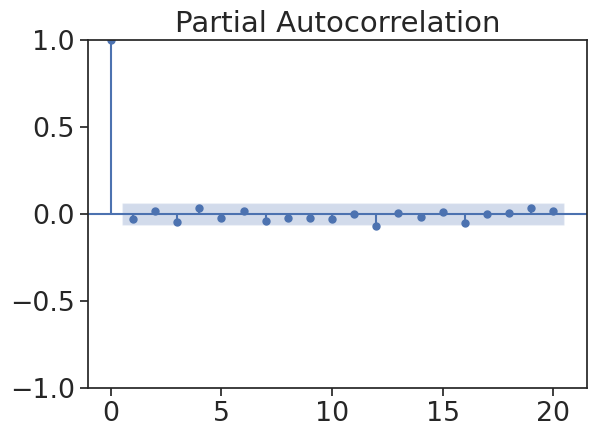

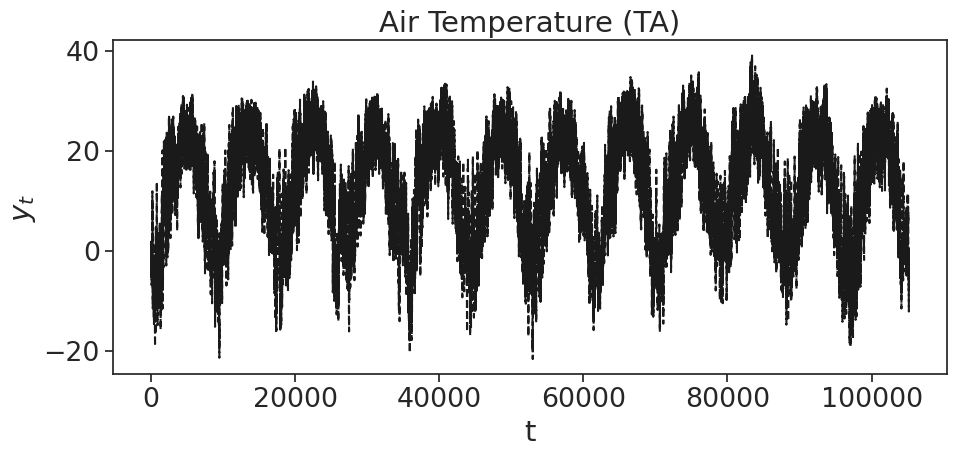

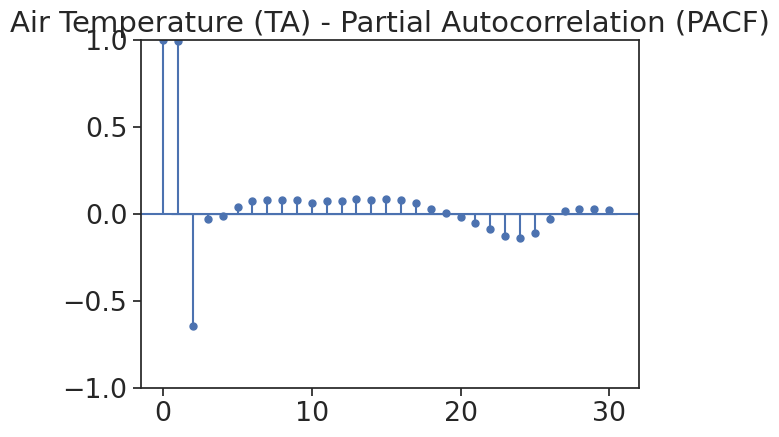

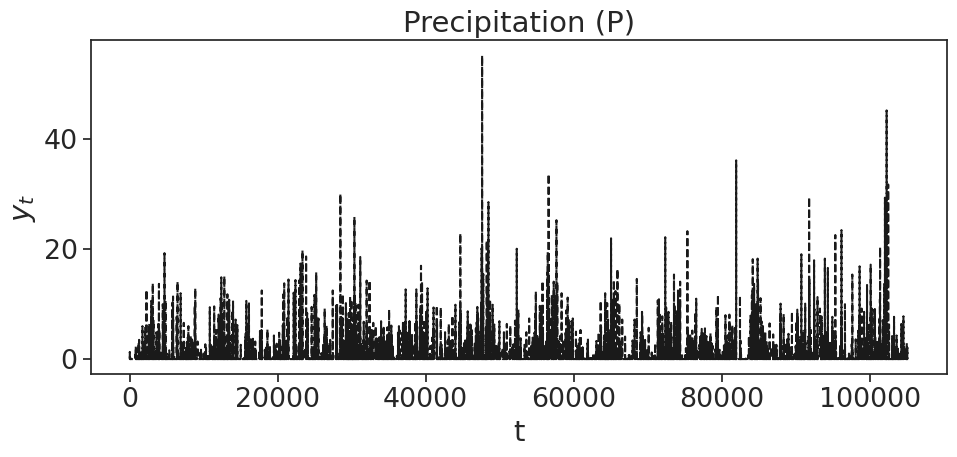

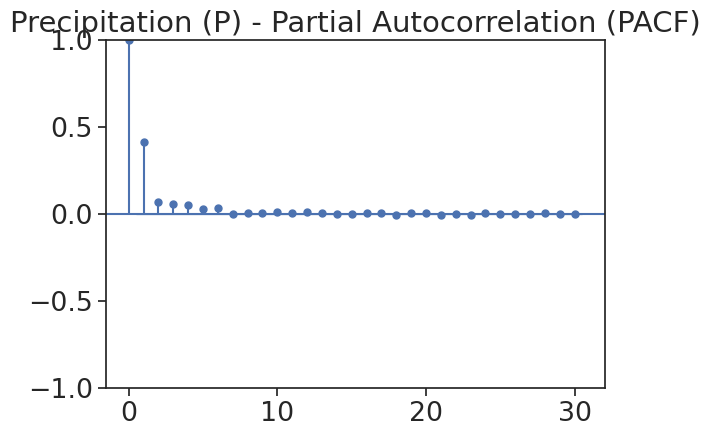

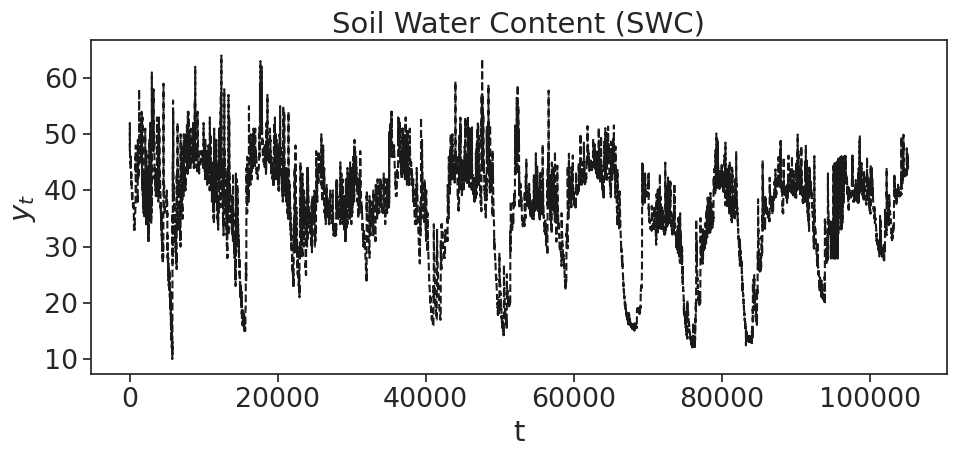

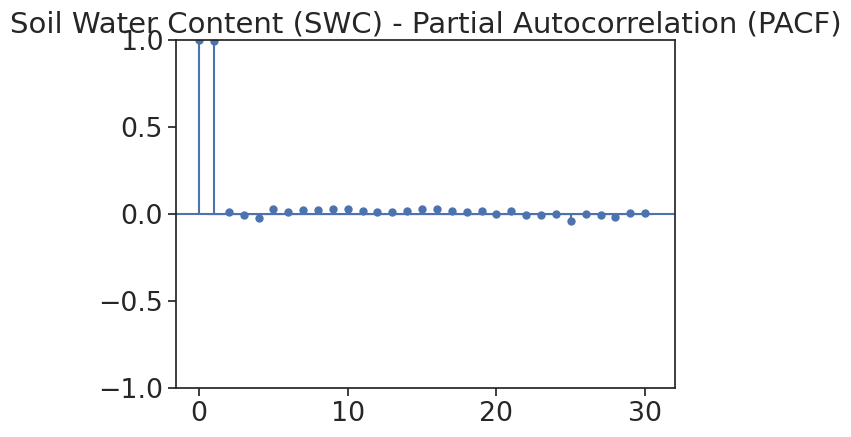

In [ ]:
random.seed(1)
N = 1000
y = norm.rvs(0,1,N)

nlags = 20
plot_pacf(y,lags=nlags).figure.tight_layout()

def diagnose_ac(y,title=''):
    plt.figure(figsize=(10,5))
    plt.plot(y,'--k')
    plt.xlabel('t')
    plt.ylabel('$y_t$')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    nlags = 30
    # plot_acf(y,lags=nlags, title=f'{title} - Autocorrelation (ACF)')
    # plt.tight_layout()
    # plt.show()

    plot_pacf(y,lags=nlags, method='ywm', title=f'{title} - Partial Autocorrelation (PACF)')
    plt.tight_layout()
    plt.show()

#diagnose_ac(y,'White noise')


random.seed(1)
N = 1000

y = np.zeros(N)
for t in range(1,N):
    y[t] = y[t-1] + norm.rvs(0,1,1)

#diagnose_ac(y,'Random walk')


random.seed(1)

N = 1000

y = np.zeros(N)
for t in range(2,N):
    y[t] = y[t-1] - 0.9*y[t-2] + norm.rvs(0,1,1)

#diagnose_ac(y,'AR2')

diagnose_ac(df['TA'].dropna(), title='Air Temperature (TA)')

diagnose_ac(df['P'].dropna(), title='Precipitation (P)')

diagnose_ac(df['SWC'].dropna(), title='Soil Water Content (SWC)')


In air temperature, I saw a very positive spike in Lag 1, which is normal. At Lag 2 and after, the spike drops automatically and turns negative. After lag 3, it normalizes to average slightly above 0 while sometimes falling slightly below it. This suggests that it has a short-term autoregressive memory meaning that it is very directly dependent on yesturday's temperature.

For precipitation, Lag 1 is very high while lag 2 is lower but not entirely on the opposite scale. After the 3rd lag, it seems completely flat. This suggests that it oes not have any temporal memory and bevaves similiar to how we saw white noise in class.

For soil water content, both Lag 1 and Lag 2 are very high in their spike and after Lag 3, it becomes flat. This shows that there is influence from the day before because when it comes to soil moisture, it does not drastically change from the day before. Instead, it dries out gradually through drainage and evaporation.

## b.
Use SWC records **before 09/01/2014** to build an autoregressive model for
predicting next-day SWC. Describe how you choose the number of time lags in
the model. Report the model accuracy and the predicted soil moisture value for
09/01/2014. Compare the predicted value with the observed SWC on 09/01/2014.
How well does the model perform?

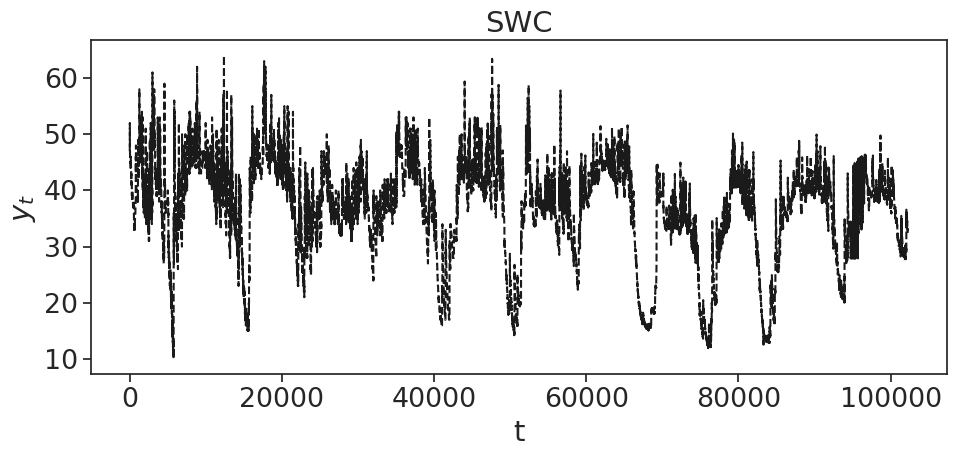

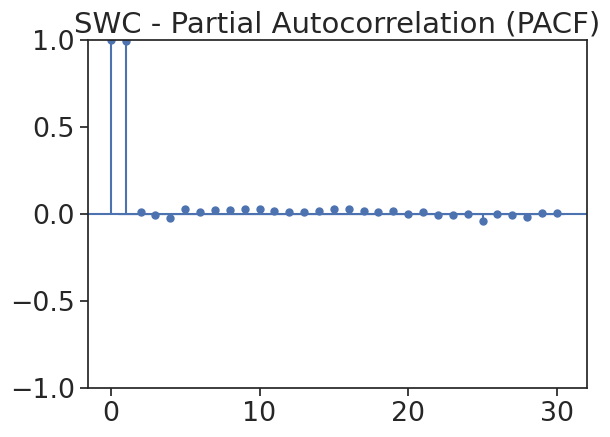

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 7.641e+06
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:54:35   Log-Likelihood:                -88409.
No. Observations:              102260   AIC:                         1.768e+05
Df Residuals:                  102256   BIC:                         1.769e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0802      0.008     10.297      0.0

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

date = df[df['Date'] < '2014-09-01']

swc = date['SWC'].values


diagnose_ac(swc,title='SWC')

# build a linear regression model
y = swc[3:] #yt
x = sm.add_constant(np.column_stack([swc[2:-1],swc[1:-2],swc[0:-3]])) #[1,yt-1,yt-2]


AR2_model = sm.OLS(y,x).fit()
print(AR2_model.summary())


# extract regression coefficients and the standard deviation of the residual
b = AR2_model.params
yhat = AR2_model.predict(x)
residuals = y-yhat
sigma = np.std(residuals)
print(b,sigma)


last3 = swc[-3:]

x_new = np.array([
    1,
    last3[2],
    last3[1],
    last3[0]
])

pred_swc = AR2_model.predict(x_new)[0]

print('Predicted SWC =',pred_swc)

actual_date = df[df['Date'] == '2014-09-01']

obs_swc = actual_date['SWC'].iloc[0]

print('Observed SWC =',obs_swc)
print('Prediction Error =',pred_swc - obs_swc)
print('Absolute Error =',abs(pred_swc - obs_swc))


Describe how you choose the number of time lags in
the model. Report the model accuracy and the predicted soil moisture value for
09/01/2014. Compare the predicted value with the observed SWC on 09/01/2014.
How well does the model perform?

After seeing the resuls of the Partal autocorrelation function, I saw that the first three lagged valued contained most of the predictive information. The predicted soil moisture on 09/01/2014 was 32.4655 while the observed SWC on this day was 32.4570 so the accuracy was very high and the model performed very good. The R^2 of the model was 0.996, which means it explained 99.6% of the variability in soil moisture.

# 2. Spatial Data Analysis (6 points)

In [ ]:
fia = pd.read_csv('/content/drive/MyDrive/GEOG191_Data/FIA_plots_CA_NV.csv')

## a.
Use the dataset FIA_plots_CA_NV.csv, which contains tree survey data from
plots in the Forest Inventory and Analysis network of the U.S. Forest Service in
California and Nevada. Analyze the spatial patterns of elevation, surveyed canopy
height (Height), and diameter at breast height (DBH).

           Elevation    Height       DBH
Elevation   1.000000 -0.319597  0.031610
Height     -0.319597  1.000000  0.750961
DBH         0.031610  0.750961  1.000000


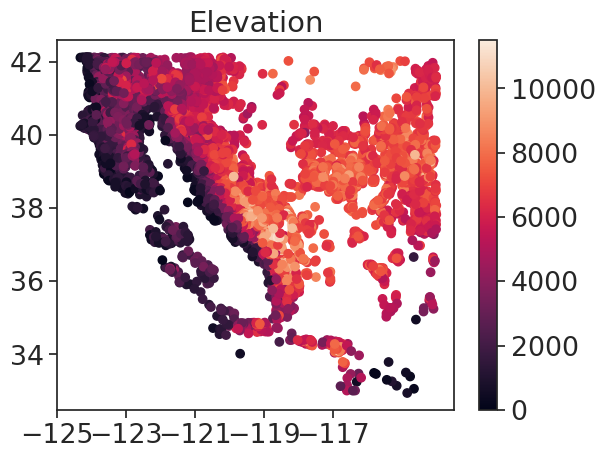

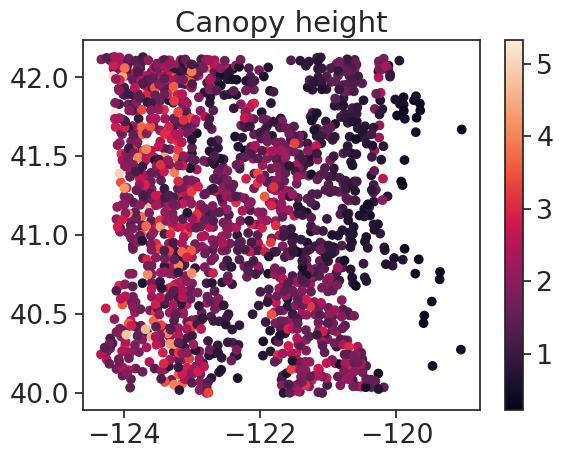

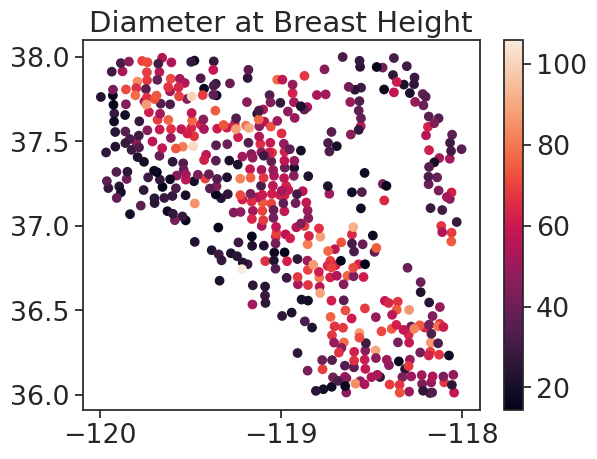

In [ ]:
nca = fia[(fia['Long']<-119) & (fia['Lat']>40)]
sierra = fia[(fia['Long']<-118) & (fia['Long']>-120) & (fia['Lat']<38) & (fia['Lat']>36)]

plt.figure()
plt.scatter(fia['Long'],fia['Lat'],c=fia['Elevation'])
plt.title('Elevation')
plt.colorbar()
plt.xticks(np.arange(-125,-115,2))

plt.figure()
plt.scatter(nca['Long'],nca['Lat'],c=nca['Height'])
plt.title('Canopy height')
plt.colorbar()


plt.figure()
plt.scatter(sierra['Long'],sierra['Lat'],c=sierra['DBH'])
plt.title('Diameter at Breast Height')
plt.colorbar()


print(fia[['Elevation','Height','DBH']].corr())

Analyze the spatial patterns of elevation, surveyed canopy height (Height), and diameter at breast height (DBH).

There is a moderate negative relationship between elevation and canopy height that suggests that trees tend to be shorter at higher elevations. On the other hand, there is a very weak positive relationship between elevation and DBH meaning that tree diameter does not have a strong linear dependence on elevation across the study area. Lastly, canopy height and DBH had the strongest relationship showing that taller trees tend to have larger drunk diameters.

## b.
Plot the empirical variograms of elevation, canopy height and DBH. Describe the
spatial patterns of the variables based on the estimated variogram parameters,
including nugget, sill, and range. Rank the three variables by their spatial
correlation in descending order

In [ ]:
pip install scikit-gstat

spherical Variogram
-------------------
Estimator:         matheron
Effective Range:   0.85
Sill:              8093294.54
Nugget:            0.00
        
spherical Variogram
-------------------
Estimator:         matheron
Effective Range:   0.69
Sill:              0.48
Nugget:            0.28
        
spherical Variogram
-------------------
Estimator:         matheron
Effective Range:   0.39
Sill:              203.26
Nugget:            176.85
        


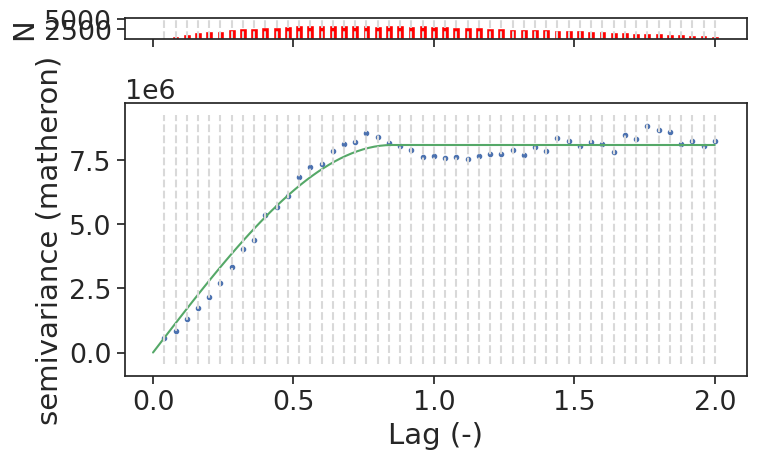

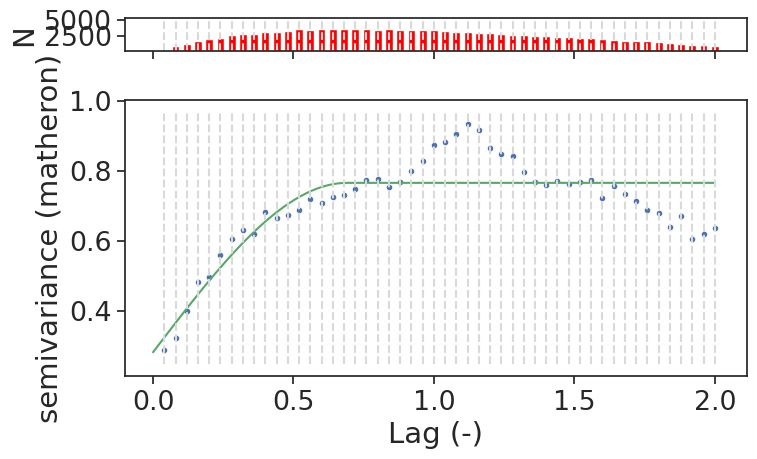

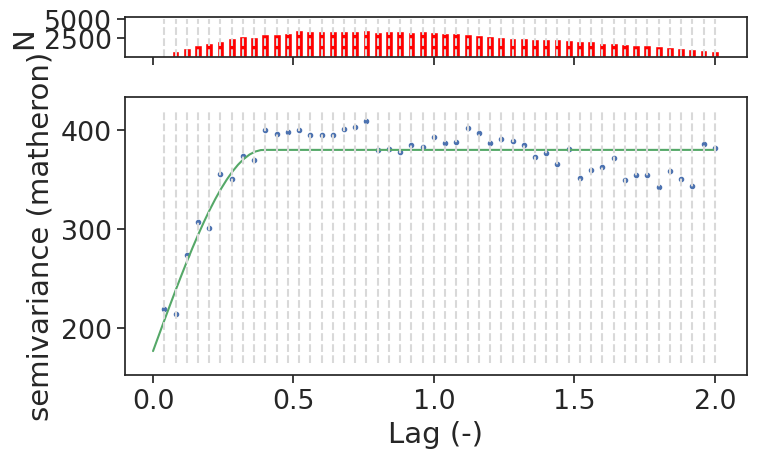

In [ ]:
import skgstat as skg

# Use skg to plot and fit empirical variograms using V = skg.Variogram()

V_elevation = skg.Variogram(coordinates = sierra[['Long','Lat']].values,values = sierra['Elevation'].values,
                  n_lags = 50, maxlag = 2,
                  model='Spherical',use_nugget=True) #Spherical
print(V_elevation)

V_elevation.plot().figure.tight_layout()

V_height = skg.Variogram(coordinates = sierra[['Long','Lat']].values,values = sierra['Height'].values,
                  n_lags = 50, maxlag = 2,
                  model='Spherical',use_nugget=True) #Spherical
print(V_height)

V_height.plot().figure.tight_layout()

V_dbh = skg.Variogram(coordinates = sierra[['Long','Lat']].values,values = sierra['DBH'].values,
                  n_lags = 50, maxlag = 2,
                  model='Spherical',use_nugget=True)
print(V_dbh)

V_dbh.plot().figure.tight_layout()


The nugget for elevation was 0 while the range was 0.85 and the sill was  8093294.54. This means that there is a high spatial variability, little to no noise, and long spatial dependence.

The nugget for height was 0.28, its range was 0.69, and its sill was 0.48. This means that there is still local randmness, some sptial correlation, and less total variability than elevation since is has a much lower sill.

Lastly, DBH had a nugget of 176.85 while its range was 0.39 and its sill was 203.26. This means that is has a very low sptial correlation and most variability is local noise since it has a large nugget and only a small portion is spatiall structured.

To rank it, elevation has the strongest spatial autocorrelation, with heigh in second, and DBH in third.

## c.
Fit a linear regression model to explain canopy height as a function of elevation.
Then calculate the residuals from the regression model and fit an empirical
variogram to the residuals. Compare the residual variogram with the original
canopy height variogram. How are they similar or different? Explain why
removing the effect of elevation may change the spatial dependence structure

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     9.209
Date:                Sat, 06 Jun 2026   Prob (F-statistic):            0.00253
Time:                        06:54:47   Log-Likelihood:                -630.99
No. Observations:                 502   AIC:                             1266.
Df Residuals:                     500   BIC:                             1274.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3387      0.105     12.710      0.0

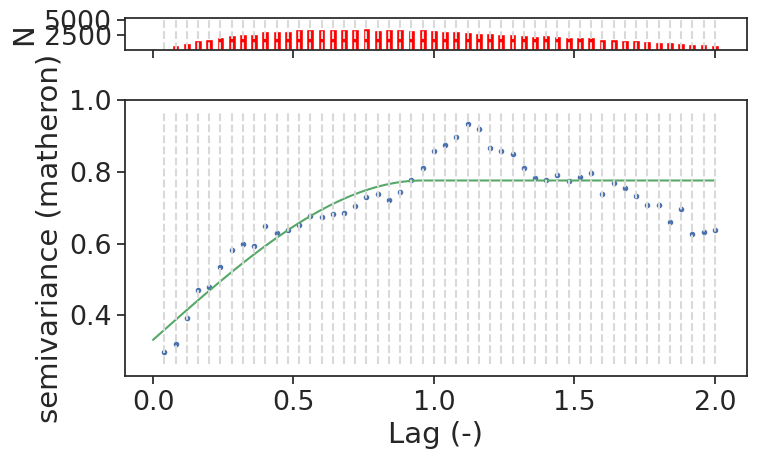

In [ ]:
y = sierra['Height'].values
x = sm.add_constant(sierra['Elevation'].values)

lm = sm.OLS(y,x).fit()
print(lm.summary())
yhat = lm.predict(x)
res = y - yhat

V_res = skg.Variogram(coordinates = sierra[['Long','Lat']].values,values = res,
                  n_lags = 50, maxlag = 2,
                  model='Spherical',use_nugget=True)
print(V_res)
V_res.plot().figure.tight_layout()

 The effective range for the residual variogram is much higher (0.96) than the origianl canopy height variogram. The sill relatively the same with only a 0.04 difference and nugget is also relatively the same with a difference of 0.05. This means that spatial dependence increased more after removing elevation because after removing elevation, there is a more spatially smoth local structure rather than elevation-driven structure. The sill had a sligt decrease in variance while the the nugget increased showing that it is now more dominated by local scale randomness.

## d.
Use ordinary kriging to estimate and map the spatial distribution of canopy height
using an exponential variogram.

In [ ]:
pip install pykrige

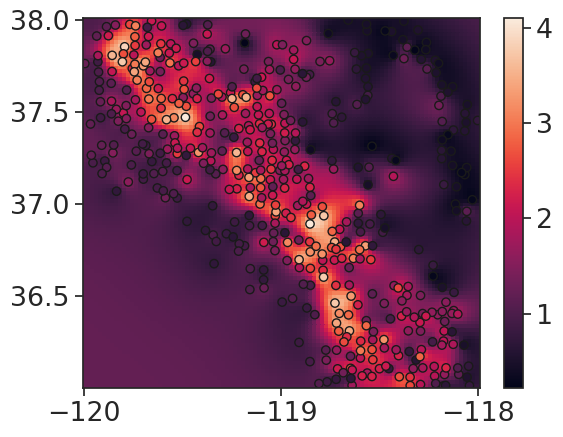

In [ ]:
from pykrige.ok import OrdinaryKriging
x0 = sierra['Long'].values
y0 = sierra['Lat'].values
z0 = sierra['Height'].values

xv = np.linspace(sierra['Long'].min(),sierra['Long'].max(),100)
yv = np.linspace(sierra['Lat'].max(),sierra['Lat'].min(),100)
xx,yy = np.meshgrid(xv,yv)

OK = OrdinaryKriging(x0,y0,z0,variogram_model='exponential')
zz_ok, ss = OK.execute("grid", xv, yv)

plt.figure();
plt.pcolor(xv,yv,zz_ok)
plt.scatter(x0,y0,c=z0,edgecolors='k')
plt.colorbar()